<a href="https://colab.research.google.com/github/aiska28/Data-Maining/blob/main/K_Means_Clustering_pada_Data_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# Load data Iris
iris = load_iris()
X_iris = iris.data

df = pd.DataFrame(X_iris, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [3]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

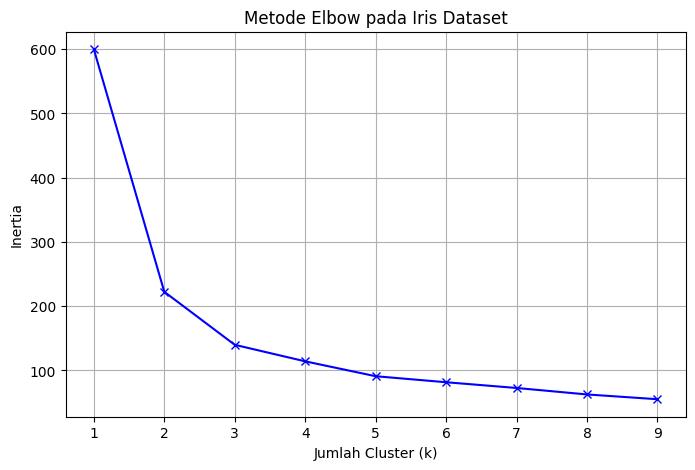

In [4]:
# Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow pada Iris Dataset')
plt.grid(True)
plt.show()

In [5]:
# Buat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Lihat hasil clustering
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


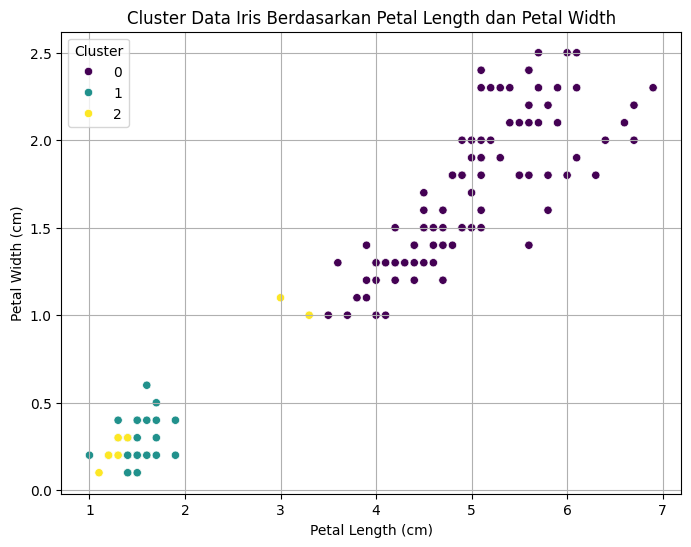

In [6]:
# Visualisasi hasil clustering
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title('Cluster Data Iris Berdasarkan Petal Length dan Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True)
plt.show()


Silhouette Score: 0.480
Inertia (k=3): 191.025


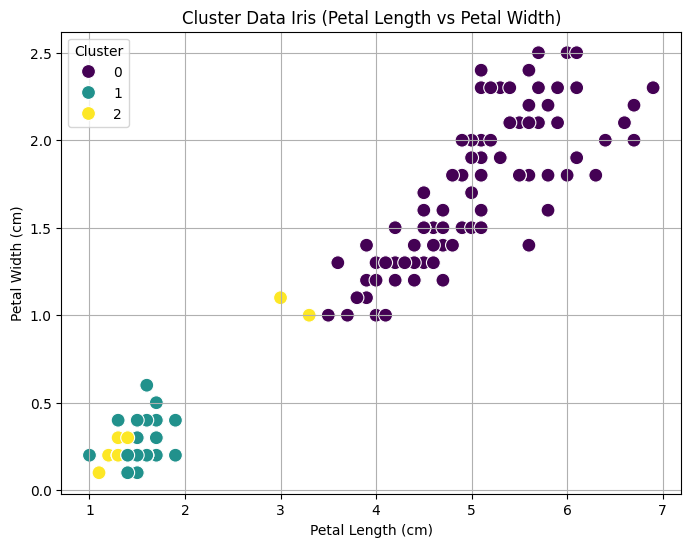

In [7]:
# 7a. Hitung Silhouette Score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")

# 7b. Tampilkan inertia akhir
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# Step 8 — Visualisasi hasil clustering (Iris)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)

plt.title('Cluster Data Iris (Petal Length vs Petal Width)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

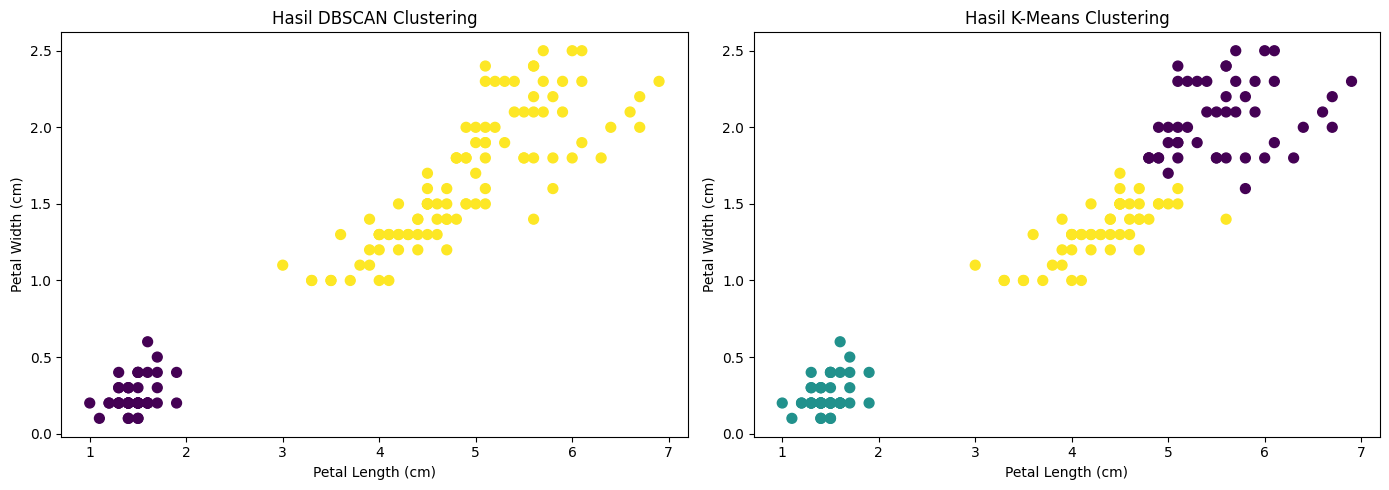

DBSCAN - Jumlah cluster: 2, Noise points: 0
K-Means - Jumlah cluster: 3


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data Iris
iris = load_iris()
X = iris.data[:, 2:4]

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Visualisasi Perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot DBSCAN
axes[0].scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='viridis', s=50)
axes[0].set_title("Hasil DBSCAN Clustering")
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")

# Plot K-Means
axes[1].scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=50)
axes[1].set_title("Hasil K-Means Clustering")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")

plt.tight_layout()
plt.show()

# Perbandingan Jumlah Cluster
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)
print(f"DBSCAN - Jumlah cluster: {n_clusters_dbscan}, Noise points: {n_noise}")
print(f"K-Means - Jumlah cluster: 3")

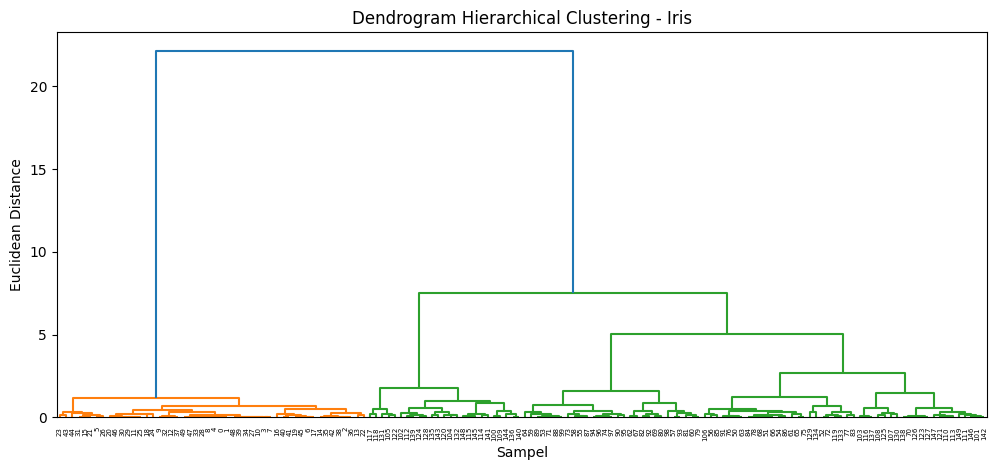

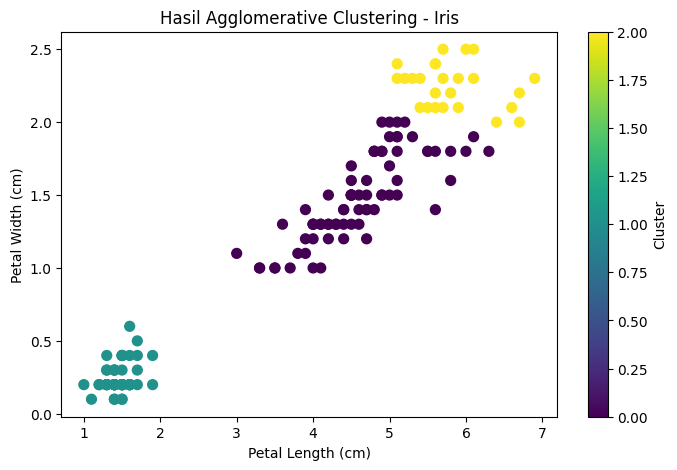

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

# Load data Iris
iris = load_iris()
X = iris.data[:, 2:4]  # Petal Length & Petal Width

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dendrogram
plt.figure(figsize=(12, 5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram Hierarchical Clustering - Iris")
plt.xlabel("Sampel")
plt.ylabel("Euclidean Distance")
plt.show()

# Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_clust.fit_predict(X_scaled)

# Visualisasi
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=agg_labels, cmap='viridis', s=50)
plt.title("Hasil Agglomerative Clustering - Iris")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.colorbar(label='Cluster')
plt.show()